# Telecom Customer Churn Prediction

## Introduction

Customer churn is a critical challenge in the telecommunications industry, where losing customers directly impacts revenue and growth. Predicting churn allows companies to proactively retain customers through targeted strategies.

In this project, a machine learning pipeline is developed to predict whether a customer is likely to churn based on demographic, service usage, and billing information.

The objective is to:
- Identify key factors influencing churn
- Build and compare multiple machine learning models
- Improve model performance using preprocessing and tuning techniques

This study applies various techniques including data preprocessing, class balance using SMOTE, feature scaling, model training, and hyperparameter tuning. 

## Dataset Description

The dataset used in this project is the Telecom Customer Churn dataset obtained from Kaggle.

- Number of records: 7043
- Features: 30+
- Target variable: Churn (Yes/No)

The dataset includes:
- Demographic information (e.g., Age, Gender)
- Service-related features (e.g., Internet Service, Contract)
- Billing information (e.g., Monthly Charges, Total Charges)

## Data Loading and Preprocessing

The following preprocessing steps were performed:

- Removed irrelevant features(e.g., Customer ID, Churn Reason)
- Handled missing values
- Converted categorical variables into numerical format using encoding
- Created target variable for churn prediction

These steps ensure the dataset is clean and suitable for machine learning models.

Load Required Libraries

In [1]:
#import essential libraries
!pip install numpy==1.24.3 pandas==1.5.3 scikit-learn==1.2.2 imbalanced-learn==0.10.1
import pandas as pd 
import numpy as np 

#For visualisation
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
#Load the dataset
df = pd.read_excel("telecom_customer_churn.xlsx",index_col = 0)

print("Dataset loaded successfully!")

#Display first few rows
df.head()

Dataset loaded successfully!


,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
Customer ID,,,,,,,,,,,,,,,,,,,,,
0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [3]:
#Display last few rows
df.tail()

,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
Customer ID,,,,,,,,,,,,,,,,,,,,,
9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,13,...,Credit Card,55.15,742.90,0.0,0,606.84,1349.74,Stayed,NaN,NaN
9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,1,22,...,Bank Withdrawal,85.10,1873.70,0.0,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,2,...,Credit Card,50.30,92.75,0.0,0,37.24,129.99,Joined,NaN,NaN
9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,67,...,Credit Card,67.85,4627.65,0.0,0,142.04,4769.69,Stayed,NaN,NaN
9995-HOTOH,Male,36,Yes,0,Sierra City,96125,39.600599,-120.636358,1,63,...,Bank Withdrawal,59.00,3707.60,0.0,0,0.00,3707.60,Stayed,NaN,NaN


Basic Dataset Inspection

In [4]:
print("No. of records in dataset: ", len(df.index))
print("No. of columns in dataset: ", len(df.columns))

No. of records in dataset:  7043
No. of columns in dataset:  37


In [5]:
#Shape of the dataset
df.shape

(7043, 37)

Column Names and Feature Overview

In [6]:
#List of columns

df.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code',
       'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months',
       'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status',
       'Churn Category', 'Churn Reason'],
      dtype='object')

Data Types and Missing Values

In [7]:
# Check for missing values
print("Total missing values in the set", sum(df.isna().sum()))

Total missing values in the set 26972


In [8]:
df.isnull().sum()

Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                   

In [9]:
#Separate numeric and Categorical columns
num_cols = df.select_dtypes(include = ["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

#Fill numerical missing values with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

#Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace = True)


In [10]:
df.isnull().sum()

Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                 

In [11]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0002-ORFBO to 9995-HOTOH
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   City                               7043 non-null   object 
 5   Zip Code                           7043 non-null   int64  
 6   Latitude                           7043 non-null   float64
 7   Longitude                          7043 non-null   float64
 8   Number of Referrals                7043 non-null   int64  
 9   Tenure in Months                   7043 non-null   int64  
 10  Offer                              7043 non-null   object 
 11  Phone Service                      7043 non-nu

Statistical Summary (Numerical Features)

In [12]:
# Summary statistics
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.446612,25.065455,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,13.495466,17.466342,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,14.455000,15.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


## Exploratory Data Analysis(EDA)

EDA was conducted to understand the distribution of features and relationships with churn.

Key observations:
- Customers with shorter tenure are more likely to churn
- Higher monthly charges are associated with higher churn rates
- Contract type significantly impacts churn behaviour

A correlation heatmap was used to identify relationships between numerical variables.

In [13]:
# Churn distribution
df["Customer Status"].value_counts()

Stayed     4720
Churned    1869
Joined      454
Name: Customer Status, dtype: int64

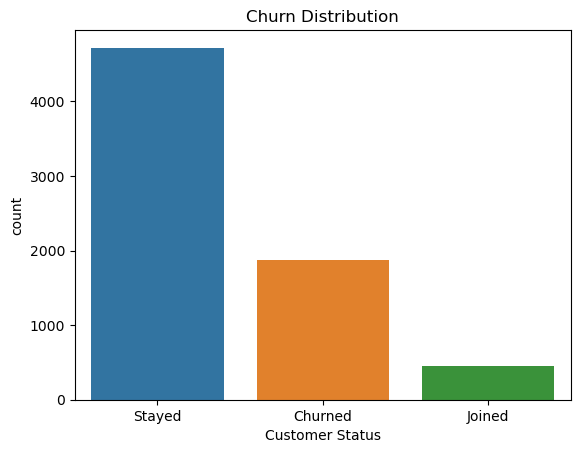

In [14]:
# Churn distribution plot
sns.countplot(x = "Customer Status", data = df)
plt.title("Churn Distribution")
plt.show()

In [15]:
# Categorical data
categorical_columns = df.select_dtypes(include = object).columns
categorical_columns

Index(['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Customer Status',
       'Churn Category', 'Churn Reason'],
      dtype='object')

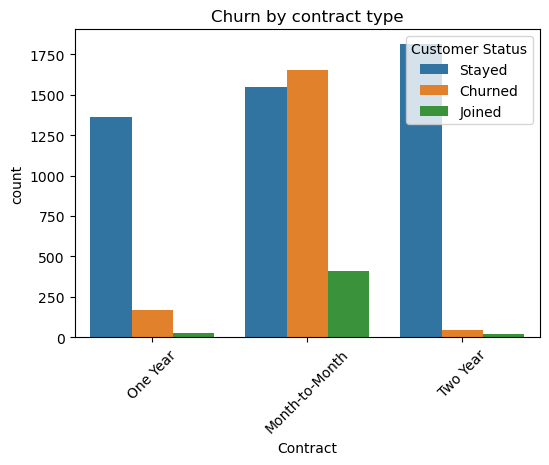

In [16]:
#Churn vs Categorical features
#Contract vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue = "Customer Status", data = df)
plt.title("Churn by contract type")
plt.xticks(rotation = 45)
plt.show()

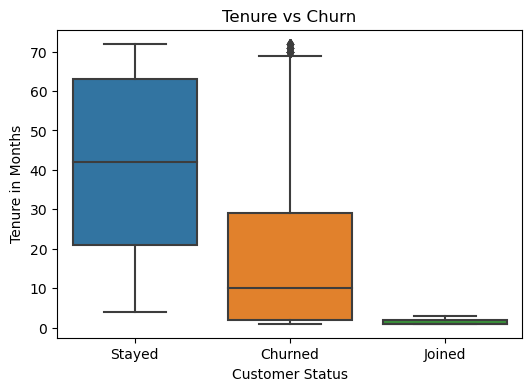

In [17]:
#Churn vs Numerical features
#Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x = "Customer Status", y="Tenure in Months", data = df)
plt.title("Tenure vs Churn")
plt.show()

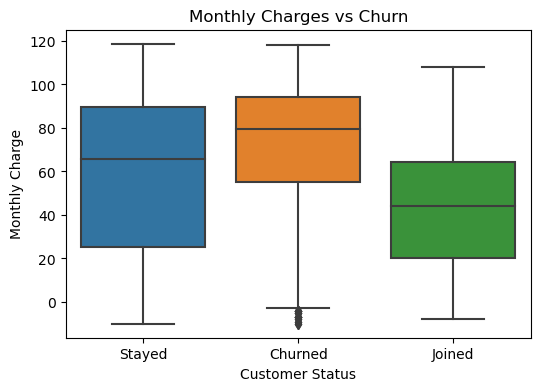

In [18]:
#Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Customer Status", y = "Monthly Charge", data = df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [19]:
df.dtypes

Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                  object
Streaming TV                          object
Streaming 

In [20]:
#convert TotalCharges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

#check missing values
df.isnull().sum()


Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                 

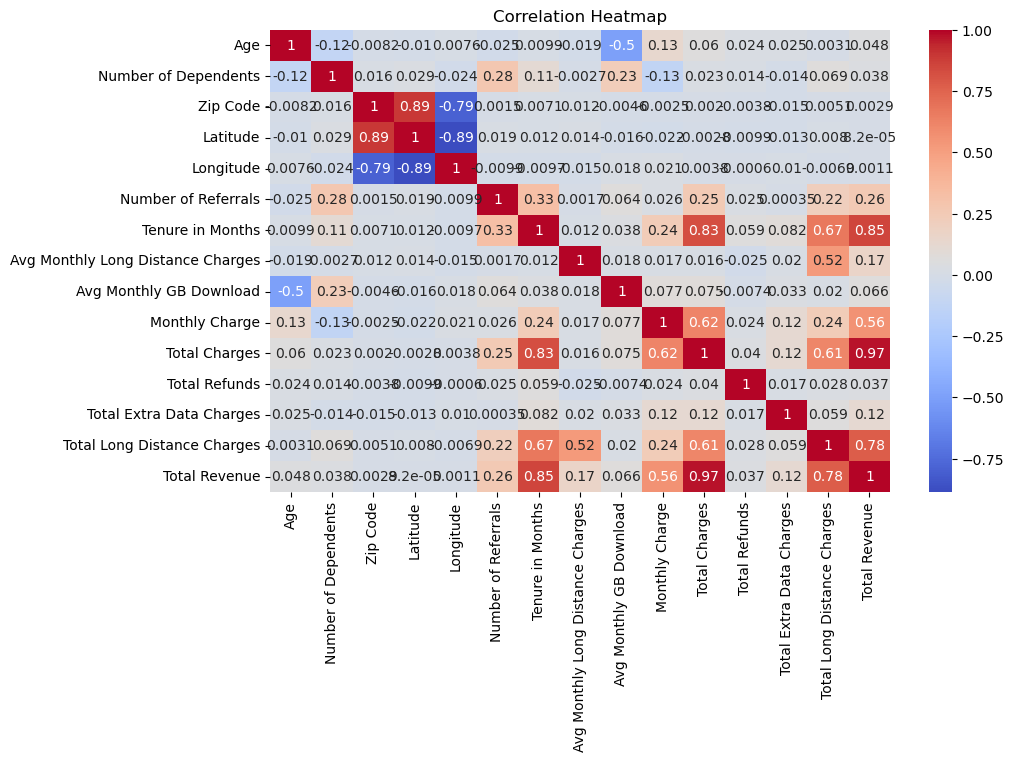

In [21]:
#Encode churn temporarily for correlation
df_corr = df.copy()
df_corr["Customer Status"].map({"Yes":1, "No": 0})

plt.figure(figsize=(10,6))
sns.heatmap(
    df_corr.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
df["Churn"] = df["Customer Status"].apply(lambda x: 1 if x == "Churned" else 0)

Drop Unnecessary Columns

In [23]:
df.index.name

'Customer ID'

In [24]:
#Drop Customer Id
df = df.reset_index(drop=True)
df.head()

,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churn
0,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,Competitor,Competitor had better devices,0
1,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Competitor,Competitor had better devices,0
2,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1


In [25]:
df.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code',
       'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months',
       'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status',
       'Churn Category', 'Churn Reason', 'Churn'],
      dtype='object')

In [26]:
# dropping unnecessary columns
df = df.drop(columns=["Customer Status", "Churn Category", "Churn Reason", "Zip Code", "Latitude", "Longitude"])

In [27]:
df.shape

(7043, 32)

In [28]:
df["Churn"].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

In [29]:
df.dtypes

Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                  object
Streaming TV                          object
Streaming Movies                      object
Streaming Music                       object
Unlimited Data                        object
Contract  

In [30]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [31]:
# Create Train-Test Split
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # stratify = y

## Handling Class Imbalance

The dataset exhibited class imbalance, with fewer churn cases compared to non-churn.

to address this, SMOTE (Synthetic Minority Oversampling Technique) was applied **only to the training dataset** to generate synthetic samples for the minority class.

This improves the model's ability to detect churn cases.

In [32]:
# handle imbalanced class using smote, only on train set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMote:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())

Before SMote:
 0    4138
1    1496
Name: Churn, dtype: int64
After SMOTE:
 0    4138
1    4138
Name: Churn, dtype: int64


## Feature Scaling

Standardization was applied using StandardScaler to normalize feature values.

This is particularly important for:
- K-Nearest Neighbours (KNN)
- Support Vector Machine (SVM)
- Logistic Regression

Scaling ensures all features contribute equally to the model.

In [33]:
# normalise/standardise train and test sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Model Selection

The following machine learning models were implemented:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbours (KNN)
- Support Vector Machine (SVM)
- Gaussian Naive Bayes

These models were selected to compare different learning approaches, including linear, tree-based, and distance-based methods.

1. Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8353442157558553

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      1036
           1       0.71      0.65      0.68       373

    accuracy                           0.84      1409
   macro avg       0.79      0.78      0.78      1409
weighted avg       0.83      0.84      0.83      1409


Confusion Matrix:
 [[935 101]
 [131 242]]


c:\Users\SANDHYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Hyperparameter Tuning

GridSearchCV was used to optimize model parameters.

This process improves model performance by identifying the best combination of parameters using cross validation.

In [35]:
# Logistic Regression with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.1, 1, 10],
    "penalty" : ["l2"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="lbfgs"),
    param_grid,
    cv=5
)

grid_log.fit(X_train_scaled, y_train_smote)

print("Best parameters:", grid_log.best_params_)

Best parameters: {'C': 0.1, 'penalty': 'l2'}


## Model Evaluation

Models were evaluated using:

- Accuracy
- Confusion Matrix
- Precision, Recall, F1-Score
- ROC Curve (AUC)

Logistic Regression achieved the best performance with:
- Accuracy: ~83%
- AUC Score: 0.88

This indicates strong ability to distinguish between churn and non-churn customers.

In [36]:
# Evaluate Tuned Model
best_log = grid_log.best_estimator_

y_pred = best_log.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7679205110007097

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1036
           1       0.56      0.59      0.57       373

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [37]:
#K-Fold Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_log, X_train_scaled, y_train_smote, cv=5)

print("Cross-validation scores", scores)
print("Average CV score:", scores.mean())

Cross-validation scores [0.7071256  0.76253776 0.90513595 0.90513595 0.91057402]
Average CV score: 0.8381018579330677


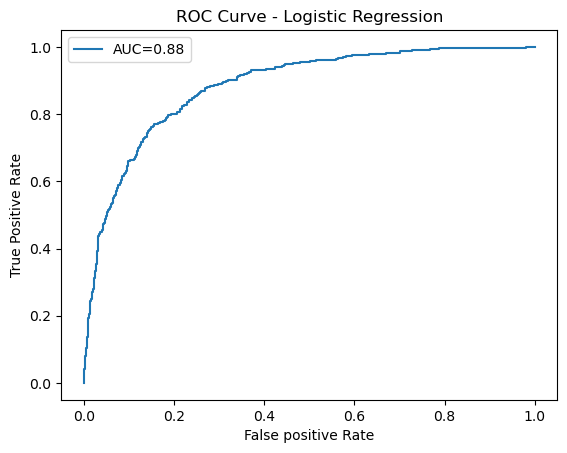

In [38]:
#ROC Curve for Logistic Regression
from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label = "AUC=" + str(round(roc_auc, 2)))
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

2. Decision Tree 

In [39]:
from sklearn.tree import DecisionTreeClassifier

#Create model
dt_model = DecisionTreeClassifier(random_state=42)

#Train model
dt_model.fit(X_train, y_train)

#Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8062455642299503

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      1036
           1       0.64      0.62      0.63       373

    accuracy                           0.81      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.81      0.81      1409


Confusion Matrix:
 [[904 132]
 [141 232]]


In [40]:
# Decision Tree with GridSearchCV
param_grid_dt = {
    "max_depth": [5,10, None],
    "min_samples_split":[2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5)
grid_dt.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5, 10]})

In [41]:
#Evaluate
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1036
           1       0.59      0.68      0.63       373

    accuracy                           0.79      1409
   macro avg       0.74      0.76      0.74      1409
weighted avg       0.80      0.79      0.80      1409



3. Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8282469836763662

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89      1036
           1       0.75      0.53      0.62       373

    accuracy                           0.83      1409
   macro avg       0.80      0.73      0.76      1409
weighted avg       0.82      0.83      0.82      1409


Confusion Matrix:
 [[968  68]
 [174 199]]


In [43]:
# Random Forest Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [100,200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1,2]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    n_jobs=1,
    verbose = 2
)

grid_rf.fit(X_train_smote, y_train_smote)

print("Best RF Params:", grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.7s
[CV] END max

In [44]:
from sklearn.metrics import accuracy_score, classification_report

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8168914123491838
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.87      1036
           1       0.63      0.73      0.68       373

    accuracy                           0.82      1409
   macro avg       0.77      0.79      0.78      1409
weighted avg       0.83      0.82      0.82      1409



Evaluating using Confusion Matrix, Precision, Recall and F1 Score

Confusion Matrix (Visual)

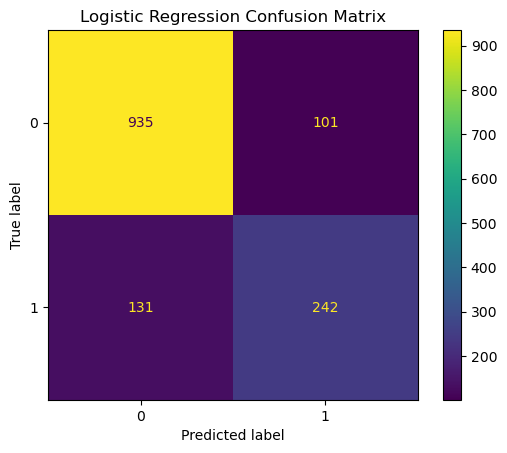

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

4. KNN

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\n Classification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.7288857345635202

 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.82      1036
           1       0.49      0.47      0.48       373

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409


Confusion Matrix:
 [[852 184]
 [198 175]]


Improve KNN (Hyperparameter Tuning)

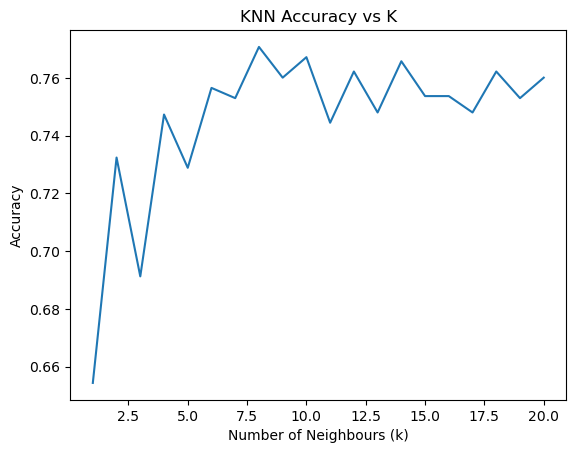

In [48]:
import matplotlib.pyplot as plt
k_values = range(1,21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies)
plt.xlabel("Number of Neighbours (k)")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

In [49]:
best_k = k_values[accuracies.index(max(accuracies))]
print("Best k:", best_k)
print("Best Accuracy:", max(accuracies))

Best k: 8
Best Accuracy: 0.7707594038325053


In [50]:
# normalise/standardise train and test sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [51]:
# KNN with GridSearch 
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    "n_neighbors": [5, 10, 15],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train_smote)

print("Best KNN Params:", grid_knn.best_params_)

Best KNN Params: {'n_neighbors': 5, 'weights': 'distance'}


In [52]:
# Evaluate

from sklearn.metrics import accuracy_score, classification_report
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6572036905606813


5. SVM Model

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.759403832505323

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85      1036
           1       0.59      0.31      0.41       373

    accuracy                           0.76      1409
   macro avg       0.69      0.62      0.63      1409
weighted avg       0.73      0.76      0.73      1409


Confusion Matrix:
 [[954  82]
 [257 116]]


In [55]:
# normalise/standardise train and test sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.svm import SVC

param_grid_svm = {
    "C": [1],
    "kernel":["linear"]
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=3)
grid_svm.fit(X_train_scaled, y_train_smote)

print("Best SVM Params:", grid_svm.best_params_)


Best SVM Params: {'C': 1, 'kernel': 'linear'}


In [57]:
#Evaluate
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7366926898509581
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1036
           1       0.50      0.71      0.59       373

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



Accuracy comparison of Models before and after Tuning 

In [58]:
import pandas as pd
results = pd.DataFrame({
    "Model":["Logistic Regression", "Decision Tree", "Random Forest Model", "KNN", "SVM"],
    "Before Tuning":[0.83, 0.80, 0.82, 0.72, 0.75],
    "After Tuning": [0.76, 0.79,0.81,0.65,0.73]
})
print(results)

                 Model  Before Tuning  After Tuning
0  Logistic Regression           0.83          0.76
1        Decision Tree           0.80          0.79
2  Random Forest Model           0.82          0.81
3                  KNN           0.72          0.65
4                  SVM           0.75          0.73


## Feature Importance

Feature importance analysis revealed that the most significant predictors include:

- Tenure in Months
- Monthly Charges
- Total Rvenue
- Contract Type

These features highlight the importance of customer engagement and billing patterns in predicting churn.

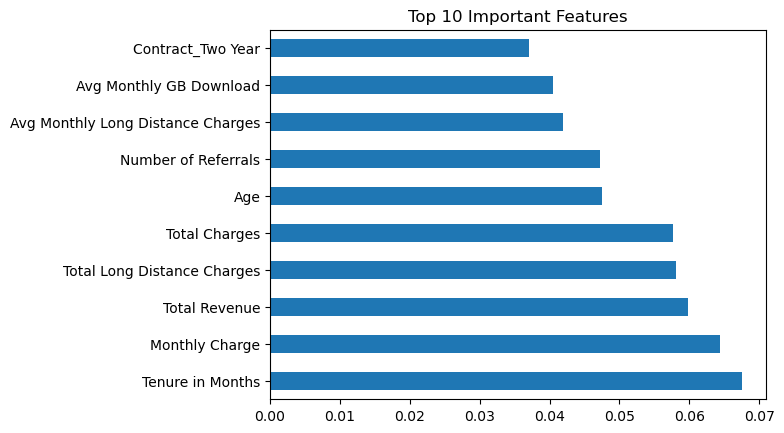

In [59]:
# Feature Importance

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

## Conclusion

This project demonstrated the application of machine learning techniques to predict customer churn.

Logistic Regression provided the best performance, suggesting that the relationship between features and churn is relatively linear.

The use of SMOTE improved the model's ability to detect churn cases, while hyperparameter tuning enhanced performance.

Future improvements could include advanced ensemble methods and further feature engineering.